# Concordance Correlation Coefficient

A regular (R)MSE or (S)MAPE value won't do for the proper evaluation of metrics. These values do not "punish" persistence-like predictions properly. Persistence-like predictions are such behaviour in which the most-recently observed value is returned as prediction. They therefore produce a timeseries that "lags" with respect to the target. Instead of predicting an increase, or a decrease, the model waits until that behaviour shows up in the feature (most recently observed input) and only then predicts those patterns. It therefore misses increases when there's an actual increase, or decreases when there's actual decreases.

For that reason, I want to make use of better metrics in evaluating models. Pearson's correlation coefficient ($\rho$) might come to mind quickly. $\rho$ depicts the extent to which two variables are linearly related. In other words, when $x_1$ consistently rises, does $x_2$ do that too? For comparing the predictions to the target that makes sense, but there's a catch: $\rho$ doesn't capture any error rate between the two variables. It only measures the strength and direction of their linear relationship.

Pearson's correlation coefficient is defined as:
\begin{equation}
\rho = \frac{\sigma_{xy}}{\sigma_x \sigma_y} = \frac{\text{Cov}(x, y)}{\sigma_x \sigma_y}
\end{equation}
where $\sigma_{xy}$ is the covariance between $x$ and $y$, and $\sigma_x$ and $\sigma_y$ are the standard deviations of $x$ and $y$ respectively.

Where the covariance is a factor of how two variables change together. Specifcally, at the deviations of each varaible from its own mean.
\begin{equation}
\text{Cov}(x, y) = \sigma_{xy} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y)
\end{equation}

The concordance correlation coefficient, or **CCC**, does capture both correlation and accuracy, however. It represents a combination of a correlation value and a classic error metric, through the following formula:
\begin{equation}
\text{CCC} = \frac{2 \sigma_{xy}}{\sigma_x^2 + \sigma_y^2 + (\mu_x - \mu_y)^2}
\end{equation}
where $\sigma_{xy}$ is the covariance, $\sigma_x^2$ and $\sigma_y^2$ are the variances of $x$ and $y$, and $\mu_x$ and $\mu_y$ are the means.

The relationship between CCC and Pearson's correlation coefficient can be expressed as:
\begin{equation}
\text{CCC} = \rho \cdot C_b
\end{equation}
where $C_b$ is a bias correction factor that accounts for the deviation from the 45-degree line of perfect concordance:
\begin{equation}
C_b = \frac{2}{\frac{\sigma_x^2 + \sigma_y^2}{2\sigma_x\sigma_y} + \frac{(\mu_x - \mu_y)^2}{\sigma_x\sigma_y}}
\end{equation}

This shows that CCC equals Pearson's $\rho$ only when there is perfect agreement (no bias), meaning $\mu_x = \mu_y$ and $\sigma_x = \sigma_y$. Otherwise, CCC will be lower than $\rho$, penalizing predictions that are correlated but systematically biased or have different scales.

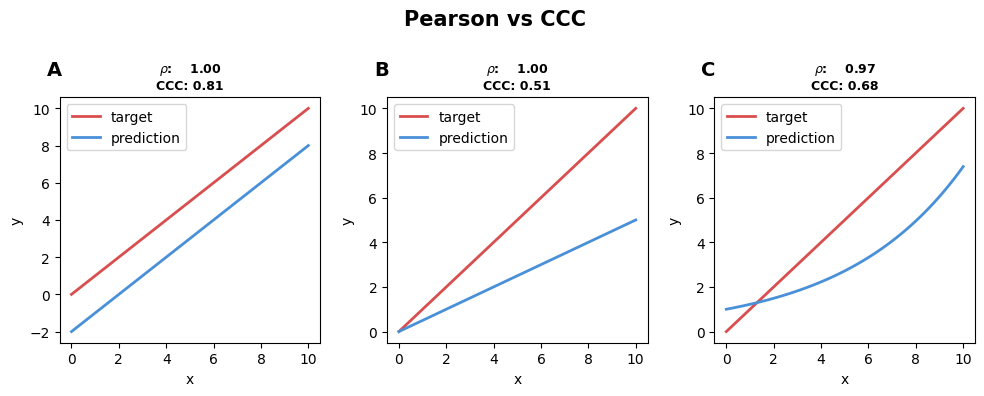

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import testcolor, traincolor

def concordance_correlation_coefficient(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov_xy = np.cov(x, y)[0, 1]
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc


x = np.linspace(0, 10, 100)

df              = pd.DataFrame(x, columns=["x"])
df['target']    = df['x']
df['pred1']     = df['x'] - 2
df['pred2']     = 0.5 * df['x']
df['pred3']     = np.exp(df['x'] / 5)

pred_columns    = ['pred1', 'pred2', 'pred3']
labels          = ['A', 'B', 'C']

fig, axes   = plt.subplots(1, 3, figsize=(10, 4))
axes        = axes.flatten()

for i, pred_col in enumerate(pred_columns):
    # Pearson Correlation
    pearson_corr = df['target'].corr(df[pred_col])
    
    # Concordance Correlation Coefficient (CCC)
    ccc_value = concordance_correlation_coefficient(df['target'], df[pred_col])
    
    # Set the title for the subplot with aligned P and CCC
    title_text = f'$\\rho$:  {pearson_corr:>6.2f}\nCCC: {ccc_value:>4.2f}'

    axes[i].set_title(title_text, fontsize=9, fontweight='bold')
    axes[i].text(-0.05, 1.15, labels[i], transform=axes[i].transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
    
    # Plot the lines for target and prediction
    sns.lineplot(df, x='x', y='target', label='target',     color=testcolor,  ax=axes[i], linewidth=2)
    sns.lineplot(df, x='x', y=pred_col, label='prediction', color=traincolor, ax=axes[i], linewidth=2)

    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

# Adjust layout
fig.suptitle('Pearson vs CCC',  fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()